## Téléchargement

In [ ]:
# =========================================================
# INSTALLATION
# =========================================================

!pip install duckdb pyarrow pandas folium -q

# =========================================================
# IMPORTS
# =========================================================

import duckdb
import pandas as pd
from google.colab import drive

# =========================================================
# GOOGLE DRIVE
# =========================================================

drive.mount('/content/drive')

# =========================================================
# CHEMIN DU PARQUET
# =========================================================

path = "/content/drive/MyDrive/data/GeolocalisationEtablissement_Sirene_pour_etudes_statistiques_utf8.parquet"

# =========================================================
# AFFICHER LE SCHEMA DU FICHIER
# =========================================================

query = f"""
DESCRIBE SELECT * FROM read_parquet('{path}')
"""

schema = duckdb.query(query).to_df()

print(schema)

# =========================================================
# AFFICHER QUELQUES LIGNES
# =========================================================

query2 = f"""
SELECT *
FROM read_parquet('{path}')
LIMIT 5
"""

sample = duckdb.query(query2).to_df()

print(sample.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
           column_name column_type null   key default extra
0                siret     VARCHAR  YES  None    None  None
1                    x       FLOAT  YES  None    None  None
2                    y       FLOAT  YES  None    None  None
3           qualite_xy     VARCHAR  YES  None    None  None
4                 epsg     VARCHAR  YES  None    None  None
5             plg_qp24     VARCHAR  YES  None    None  None
6             plg_iris     VARCHAR  YES  None    None  None
7              plg_zus     VARCHAR  YES  None    None  None
8             plg_qp15     VARCHAR  YES  None    None  None
9              plg_qva     VARCHAR  YES  None    None  None
10    plg_code_commune     VARCHAR  YES  None    None  None
11  distance_precision       FLOAT  YES  None    None  None
12        qualite_qp24     VARCHAR  YES  None    None  None
13        qualite_iris     VARC

In [ ]:
import os

data_dir = '/content/drive/MyDrive/data/'
print(f"Checking contents of {data_dir}:")
if os.path.exists(data_dir):
    files_in_data = [f for f in os.listdir(data_dir) if f.endswith('.gpkg')]
    if files_in_data:
        print("Found GPKG files:")
        for f in files_in_data:
            print(f"- {f}")
    else:
        print("No .gpkg files found in the data directory.")
else:
    print("Data directory does not exist.")

Checking contents of /content/drive/MyDrive/data/:
Found GPKG files:
- grille200m_alsace_t5km_3948_202603telecharge.gpkg
- sirene_67.gpkg
- sirene_68.gpkg


# **Fusion des établissements SIRENE Alsace (Bas-Rhin + Haut-Rhin)**

Fusionner les deux couches départementales SIRENE :

Bas-Rhin (67) & Haut-Rhin (68)

afin d’obtenir : une couche unique des établissements d’Alsace.

In [ ]:
# =========================================================
# BLOC 1
# FUSION SIRENE 67 + 68
# SORTIE :
# sirene_alsace_fusion_all.gpkg
# =========================================================

!pip install geopandas pyogrio -q

import geopandas as gpd
import pandas as pd
import gc

# =========================================================
# PATHS
# =========================================================

path67 = "/content/drive/MyDrive/data/sirene_67.gpkg"
path68 = "/content/drive/MyDrive/data/sirene_68.gpkg"

out_path = "/content/drive/MyDrive/data/sirene_alsace_fusion_all.gpkg"

# =========================================================
# LECTURE
# =========================================================

gdf67 = gpd.read_file(path67)
gdf68 = gpd.read_file(path68)

# =========================================================
# INFOS
# =========================================================

print("\n==============================")
print("COUCHE : SIRENE 67")
print("==============================")
print("Nombre de colonnes :", len(gdf67.columns))
print("Colonnes :", list(gdf67.columns))
print("CRS :", gdf67.crs)

print("\n==============================")
print("COUCHE : SIRENE 68")
print("==============================")
print("Nombre de colonnes :", len(gdf68.columns))
print("Colonnes :", list(gdf68.columns))
print("CRS :", gdf68.crs)

# =========================================================
# FUSION
# =========================================================

gdf_final = pd.concat([gdf67, gdf68], ignore_index=True)

# =========================================================
# CRS
# =========================================================

gdf_final = gdf_final.to_crs(3948)

# =========================================================
# EXPORT
# =========================================================

gdf_final.to_file(out_path, driver="GPKG")

print("\n=================================================")
print("FUSION TERMINEE")
print("=================================================")
print("Nombre total objets :", len(gdf_final))
print("Sortie :", out_path)

# =========================================================
# CLEAN RAM
# =========================================================

del gdf67, gdf68
gc.collect()


COUCHE : SIRENE 67
Nombre de colonnes : 7
Colonnes : ['siret', 'x_longitude', 'y_latitude', 'plg_code_commune', 'trancheEffectifsEtablissement', 'emplois_estimes', 'geometry']
CRS : EPSG:3948

COUCHE : SIRENE 68
Nombre de colonnes : 7
Colonnes : ['siret', 'x_longitude', 'y_latitude', 'plg_code_commune', 'trancheEffectifsEtablissement', 'emplois_estimes', 'geometry']
CRS : EPSG:3948

FUSION TERMINEE
Nombre total objets : 875690
Sortie : /content/drive/MyDrive/data/sirene_alsace_fusion_all.gpkg


0

# **Nettoyage et hiérarchisation fonctionnelle des établissements**

Supprimer les établissements sans salariés

Créer un score hiérarchique d’intensité fonctionnelle des emplois (1-5)

In [ ]:
# =========================================================
# BLOC 2
# TRI + SCORE EMPLOI
#
# ENTREES :
# sirene_alsace_fusion_all.gpkg
#
# SORTIE :
# sirene_alsace_fusion_tri.gpkg
# =========================================================

!pip install geopandas pyogrio -q

import geopandas as gpd
import numpy as np

# =========================================================
# PATH
# =========================================================

input_path = "/content/drive/MyDrive/data/sirene_alsace_fusion_all.gpkg"

output_path = "/content/drive/MyDrive/data/sirene_alsace_fusion_tri.gpkg"

# =========================================================
# LECTURE
# =========================================================

gdf = gpd.read_file(input_path)

# =========================================================
# INFOS
# =========================================================

print("\n==============================")
print("COUCHE : SIRENE FUSION")
print("==============================")
print("Nombre de colonnes :", len(gdf.columns))
print("Colonnes :", list(gdf.columns))
print("CRS :", gdf.crs)

# =========================================================
# SUPPRESSION NN / 00
# =========================================================

gdf = gdf[
    ~gdf["trancheEffectifsEtablissement"].isin(["NN", "00"])
]

print("\nApres suppression NN/00 :", len(gdf))

# =========================================================
# SCORE EMPLOI
# =========================================================

score_mapping = {

    # TPE
    "01": 1,
    "02": 1,
    "03": 1,

    # PME petit
    "11": 2,
    "12": 2,

    # PME moyen
    "21": 3,
    "22": 3,
    "31": 3,

    # ETI
    "32": 4,
    "41": 4,
    "42": 4,
    "51": 4,

    # GE
    "52": 5,
    "53": 5
}

# =========================================================
# AJOUT SCORE
# =========================================================

gdf["score_emploi"] = (
    gdf["trancheEffectifsEtablissement"]
    .map(score_mapping)
)

# =========================================================
# VERIFICATION
# =========================================================

print("\n==============================")
print("DISTRIBUTION SCORE")
print("==============================")

print(
    gdf["score_emploi"]
    .value_counts(dropna=False)
    .sort_index()
)

# =========================================================
# EXPORT
# =========================================================

gdf.to_file(output_path, driver="GPKG")

print("\n=================================================")
print("EXPORT TERMINE")
print("=================================================")
print("Sortie :", output_path)


COUCHE : SIRENE FUSION
Nombre de colonnes : 7
Colonnes : ['siret', 'x_longitude', 'y_latitude', 'plg_code_commune', 'trancheEffectifsEtablissement', 'emplois_estimes', 'geometry']
CRS : EPSG:3948

Apres suppression NN/00 : 58477

DISTRIBUTION SCORE
score_emploi
1.0    45960
2.0    10098
3.0     2126
4.0      282
5.0        3
NaN        8
Name: count, dtype: int64

EXPORT TERMINE
Sortie : /content/drive/MyDrive/data/sirene_alsace_fusion_tri.gpkg


# **Agrégation spatiale des scores d’emplois par grille INSEE 200 m**

In [ ]:
# =========================================================
# BLOC 3
# JOINTURE SPATIALE
# SOMME SCORE EMPLOI PAR GRILLE 200m
#
# ENTREES :
# sirene_alsace_fusion_tri.gpkg
# grille200m_alsace_t5km_3948_202603telecharge.gpkg
#
# SORTIE :
# grille_finale_attractivite_emploi.gpkg
# =========================================================

!pip install geopandas pyogrio shapely rtree -q

import geopandas as gpd
import pandas as pd

# =========================================================
# PATHS
# =========================================================

points_path = "/content/drive/MyDrive/data/sirene_alsace_fusion_tri.gpkg"

grid_path = "/content/drive/MyDrive/data/grille200m_alsace_t5km_3948_202603telecharge.gpkg"

output_path = "/content/drive/MyDrive/data/grille_finale_attractivite_emploi.gpkg"

# =========================================================
# LECTURE
# =========================================================

points = gpd.read_file(points_path)
grid = gpd.read_file(grid_path)

# =========================================================
# CRS
# =========================================================

points = points.to_crs(3948)
grid = grid.to_crs(3948)

# =========================================================
# INFOS
# =========================================================

print("\n==============================")
print("COUCHE : POINTS EMPLOIS")
print("==============================")
print("Nombre de colonnes :", len(points.columns))
print("Colonnes :", list(points.columns))
print("CRS :", points.crs)

print("\n==============================")
print("COUCHE : GRILLE")
print("==============================")
print("Nombre de colonnes :", len(grid.columns))
print("Colonnes :", list(grid.columns))
print("CRS :", grid.crs)

# =========================================================
# JOINTURE SPATIALE
# =========================================================

join = gpd.sjoin(
    points,
    grid[["idINSPIRE", "geometry"]],
    how="inner",
    predicate="within"
)

# =========================================================
# SOMME SCORE
# =========================================================

agg = (
    join.groupby("idINSPIRE")["score_emploi"]
    .sum()
    .reset_index()
)

agg.columns = ["idINSPIRE", "sum_score"]

# =========================================================
# JOINTURE TABLE
# =========================================================

grid_final = grid.merge(
    agg,
    on="idINSPIRE",
    how="left"
)

# =========================================================
# REMPLACER NaN
# =========================================================

grid_final["sum_score"] = (
    grid_final["sum_score"]
    .fillna(0)
)

# =========================================================
# INFOS
# =========================================================

print("\n==============================")
print("RESULTAT FINAL")
print("==============================")
print("Nombre objets :", len(grid_final))

print("\nStatistiques sum_score :")
print(grid_final["sum_score"].describe())

# =========================================================
# EXPORT
# =========================================================

grid_final.to_file(output_path, driver="GPKG")

print("\n=================================================")
print("EXPORT TERMINE")
print("=================================================")
print("Sortie :", output_path)


COUCHE : POINTS EMPLOIS
Nombre de colonnes : 8
Colonnes : ['siret', 'x_longitude', 'y_latitude', 'plg_code_commune', 'trancheEffectifsEtablissement', 'emplois_estimes', 'score_emploi', 'geometry']
CRS : EPSG:3948

COUCHE : GRILLE
Nombre de colonnes : 2
Colonnes : ['idINSPIRE', 'geometry']
CRS : EPSG:3948

RESULTAT FINAL
Nombre objets : 250872

Statistiques sum_score :
count    250872.000000
mean          0.293684
std           2.472159
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         278.000000
Name: sum_score, dtype: float64

EXPORT TERMINE
Sortie : /content/drive/MyDrive/data/grille_finale_attractivite_emploi.gpkg


# **Analyse statistique et visualisation des scores d’attractivité emploi**


COUCHE : EMPLOI
Nombre de lignes : 250872
Nombre de colonnes : 3
CRS : EPSG:3948

APERCU
                        idINSPIRE  sum_score
0  CRS3035RES200mN2751200E4079400        0.0
1  CRS3035RES200mN2751000E4079400        0.0
2  CRS3035RES200mN2750800E4079400        0.0
3  CRS3035RES200mN2750600E4079400        0.0
4  CRS3035RES200mN2750400E4079400        0.0

Nombre de mailles avec emploi : 16559
Nombre de mailles sans emploi : 234313

STATISTIQUES GENERALES
count    16559.000000
mean         4.449363
std          8.608450
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max        278.000000
Name: sum_score, dtype: float64

INDICATEURS AVANCES
Moyenne : 4.44936288423214
Médiane : 2.0
Ecart-type : 8.608449609845431
Coefficient variation : 1.9347600620197687
Skewness : 9.516537519013713
Kurtosis : 164.347795823929

DECILES / QUANTILES
0.00      1.00
0.05      1.00
0.10      1.00
0.20      1.00
0.40      2.00
0.60      3.00
0.80      5.00
0.90      9

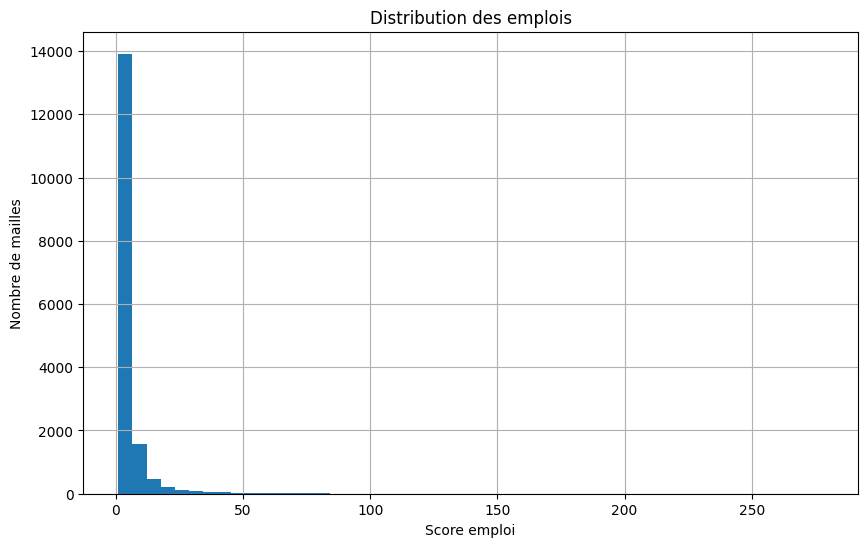

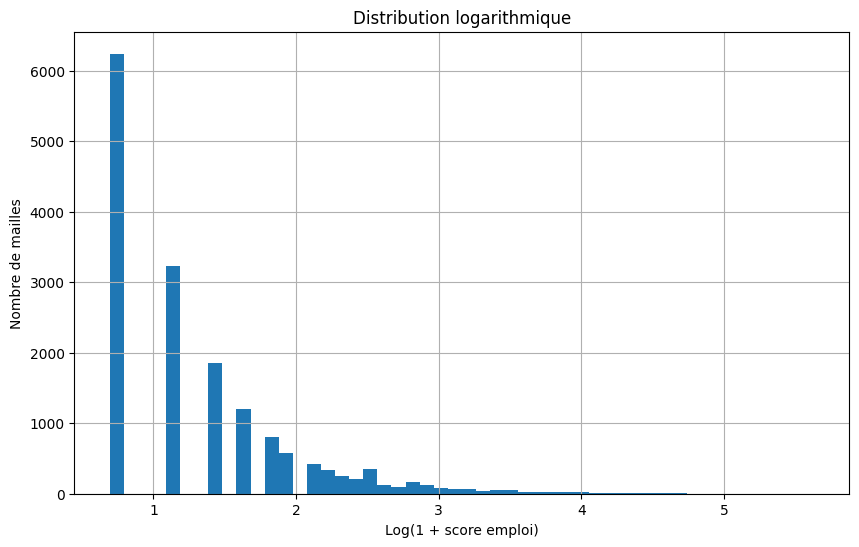

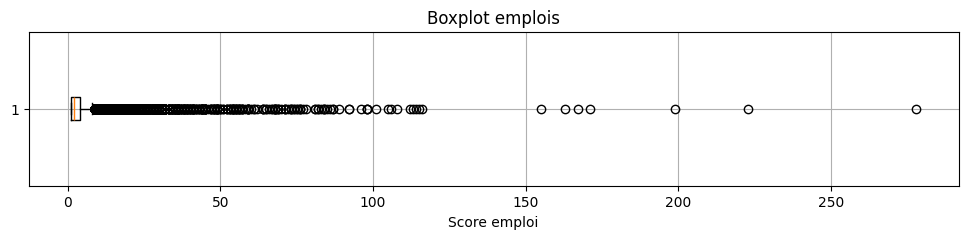


INTERPRETATION

Critères à observer :

1. Skewness
- proche de 0 :
  distribution équilibrée
- > 1 :
  forte asymétrie
  présence d'hypercentres

2. Kurtosis
- élevée :
  présence de valeurs extrêmes

3. Coefficient de variation
- élevé :
  forte hétérogénéité spatiale

4. Histogramme
- vérifier :
  - concentration spatiale
  - hypercentres d'emploi
  - queues longues

5. Classification conseillée

Distribution équilibrée :
-> quantiles

Distribution asymétrique :
-> logarithmique
-> Jenks

Présence d'hypercentres :
-> seuils manuels
-> clipping des extrêmes

IMPORTANT :
Pour l'intensité territoriale emploi,
la classification doit être réalisée
uniquement sur les valeurs > 0.
Les mailles à 0 constituent une classe
distincte hors des 5 classes d'intensité.



In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# (1) CHARGEMENT
# =========================================================

file_path = "/content/grille_finale_attractivite_emploi.gpkg"

gdf = gpd.read_file(file_path)

print("\n==============================")
print("COUCHE : EMPLOI")
print("==============================")

print("Nombre de lignes :", len(gdf))
print("Nombre de colonnes :", len(gdf.columns))
print("CRS :", gdf.crs)

# =========================================================
# (2) APERCU
# =========================================================

print("\n==============================")
print("APERCU")
print("==============================")

print(
    gdf[
        [
            "idINSPIRE",
            "sum_score"
        ]
    ].head()
)

# =========================================================
# (3) EXCLUSION DES VALEURS 0
# =========================================================

values = gdf["sum_score"].fillna(0)

values_nonzero = values[
    values > 0
]

print("\nNombre de mailles avec emploi :", len(values_nonzero))
print("Nombre de mailles sans emploi :", (values == 0).sum())

# =========================================================
# (4) STATISTIQUES GENERALES
# =========================================================

print("\n==============================")
print("STATISTIQUES GENERALES")
print("==============================")

stats = values_nonzero.describe()

print(stats)

# =========================================================
# (5) INDICATEURS AVANCES
# =========================================================

print("\n==============================")
print("INDICATEURS AVANCES")
print("==============================")

mean_val = values_nonzero.mean()
median_val = values_nonzero.median()
std_val = values_nonzero.std()

cv = std_val / mean_val

skewness = values_nonzero.skew()
kurtosis = values_nonzero.kurt()

print("Moyenne :", mean_val)
print("Médiane :", median_val)
print("Ecart-type :", std_val)

print("Coefficient variation :", cv)

print("Skewness :", skewness)
print("Kurtosis :", kurtosis)

# =========================================================
# (6) QUANTILES
# =========================================================

print("\n==============================")
print("DECILES / QUANTILES")
print("==============================")

quantiles = values_nonzero.quantile([
    0,
    0.05,
    0.10,
    0.20,
    0.40,
    0.60,
    0.80,
    0.90,
    0.95,
    0.99,
    1
])

print(quantiles)

# =========================================================
# (7) VALEURS EXTREMES
# =========================================================

print("\n==============================")
print("VALEURS EXTREMES")
print("==============================")

q1 = values_nonzero.quantile(0.25)
q3 = values_nonzero.quantile(0.75)

iqr = q3 - q1

borne_sup = q3 + 1.5 * iqr

print("Q1 :", q1)
print("Q3 :", q3)
print("IQR :", iqr)

print("Seuil outlier :", borne_sup)

outliers = values_nonzero[
    values_nonzero > borne_sup
]

print("Nombre outliers :", len(outliers))

# =========================================================
# (8) REPARTITION DES VALEURS
# =========================================================

print("\n==============================")
print("TOP VALEURS")
print("==============================")

print(
    values_nonzero
    .value_counts()
    .sort_index()
    .tail(20)
)

# =========================================================
# (9) HISTOGRAMME
# =========================================================

plt.figure(figsize=(10,6))

plt.hist(
    values_nonzero,
    bins=50
)

plt.xlabel("Score emploi")
plt.ylabel("Nombre de mailles")

plt.title(
    "Distribution des emplois"
)

plt.grid()

plt.show()

# =========================================================
# (10) HISTOGRAMME LOG
# =========================================================

plt.figure(figsize=(10,6))

plt.hist(
    np.log1p(values_nonzero),
    bins=50
)

plt.xlabel("Log(1 + score emploi)")
plt.ylabel("Nombre de mailles")

plt.title(
    "Distribution logarithmique"
)

plt.grid()

plt.show()

# =========================================================
# (11) BOXPLOT
# =========================================================

plt.figure(figsize=(12,2))

plt.boxplot(
    values_nonzero,
    vert=False
)

plt.xlabel("Score emploi")

plt.title(
    "Boxplot emplois"
)

plt.grid()

plt.show()

# =========================================================
# (12) INTERPRETATION
# =========================================================

print("\n==============================")
print("INTERPRETATION")
print("==============================")

print("""
Critères à observer :

1. Skewness
- proche de 0 :
  distribution équilibrée
- > 1 :
  forte asymétrie
  présence d'hypercentres

2. Kurtosis
- élevée :
  présence de valeurs extrêmes

3. Coefficient de variation
- élevé :
  forte hétérogénéité spatiale

4. Histogramme
- vérifier :
  - concentration spatiale
  - hypercentres d'emploi
  - queues longues

5. Classification conseillée

Distribution équilibrée :
-> quantiles

Distribution asymétrique :
-> logarithmique
-> Jenks

Présence d'hypercentres :
-> seuils manuels
-> clipping des extrêmes

IMPORTANT :
Pour l'intensité territoriale emploi,
la classification doit être réalisée
uniquement sur les valeurs > 0.
Les mailles à 0 constituent une classe
distincte hors des 5 classes d'intensité.
""")